In [53]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

import plotly.graph_objs as go
import plotly.express as px
from plotly.figure_factory import create_scatterplotmatrix
from plotly.subplots import make_subplots

In [54]:
X_train = pd.read_csv("logReg_X_train_prepared.csv")
print(f"Shape of X_train {X_train.shape}")
X_test = pd.read_csv("logReg_X_test_prepared.csv")
print(f"Shape of X_test {X_test.shape}")
y_train = pd.read_csv("logReg_y_train_prepared.csv")
print(f"Shape of y_train {y_train.shape}")
y_test = pd.read_csv("logReg_y_test_prepared.csv")
print(f"Shape of y_test {y_test.shape}")

Shape of X_train (244, 9)
Shape of X_test (105, 9)
Shape of y_train (244, 1)
Shape of y_test (105, 1)


## Modell erstellen

In [55]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
logit_model=sm.Logit(y_train,X_train)

In [56]:
result=logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.584671
         Iterations 6
                            Results: Logit
Model:                Logit              Method:             MLE       
Dependent Variable:   Outcome Variable   Pseudo R-squared:   0.154     
Date:                 2025-05-30 22:20   AIC:                305.3196  
No. Observations:     244                BIC:                340.2913  
Df Model:             9                  Log-Likelihood:     -142.66   
Df Residuals:         234                LL-Null:            -168.60   
Converged:            1.0000             LLR p-value:        4.7497e-08
No. Iterations:       6.0000             Scale:              1.0000    
-----------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                    1.7521   0.8017  2.1854 0.0289  0.1807

In der Summary zeigt sich zum Beispiel, dass Patienten mit einem hohen Cholesterin-Wert ein erhöhtes Risiko haben, eine positive Diagnose zu erhalten. 
Ebenfalls zeigt sich bei der Variable Disease_Rare ein signifikant negativer Effekt: Eine positive Diagnose ist bei seltenen Krankheiten deutlich weniger wahrscheinlich.

Hier wie die Klassenverteilung ermittelt, um die Ergebnisse korrekt intepretieren zu können:

In [57]:
print(f"Anzahl pro binäre Variable im Train {y_train['Outcome Variable'].value_counts()/len(y_train)}")
print(f"Anzahl pro binäre Variable im Test {y_test['Outcome Variable'].value_counts()/len(y_test)}")

Anzahl pro binäre Variable im Train Outcome Variable
1    0.532787
0    0.467213
Name: count, dtype: float64
Anzahl pro binäre Variable im Test Outcome Variable
1    0.533333
0    0.466667
Name: count, dtype: float64


Hier werden die Werte vorausgesagt:

In [58]:
y_pred_train_proba = result.predict(X_train)
y_pred_test_proba = result.predict(X_test)

Bei der Überführung der berechneten Wahrscheinlichkeiten in die Kategorien 1 (Positiv) und 0 (Negativ) wird ein Schwellenwert von 0.3 angenommen. Dies aus dem Grund, dass es in medizinischen Diagnosen oft kritischer ist, falsch-negativ zu klassifizieren als falsch-positiv. 

In [59]:
y_pred_train_class = (y_pred_train_proba>0.3).astype(int)
y_pred_test_class = (y_pred_test_proba>0.3).astype(int)

## Evaluation

### Konfusionsmatrix

Die Konfusionsmatrix des Training Sample ist:


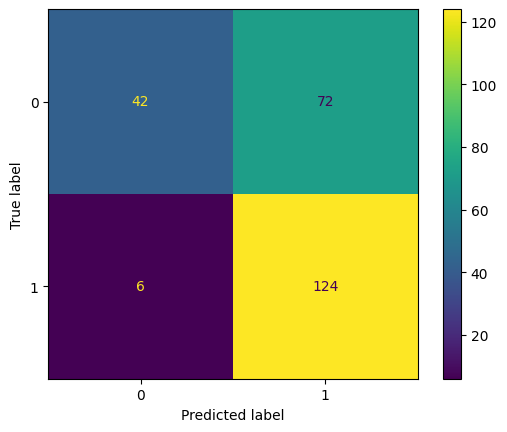

In [60]:
# Train Confusion Matrix
confusion_matrix_train = metrics.confusion_matrix(y_train, y_pred_train_class)
print(f"Die Konfusionsmatrix des Training Sample ist:")
metrics.ConfusionMatrixDisplay(confusion_matrix_train).plot()

Die Konfusionsmatrix des Training Sample ist:


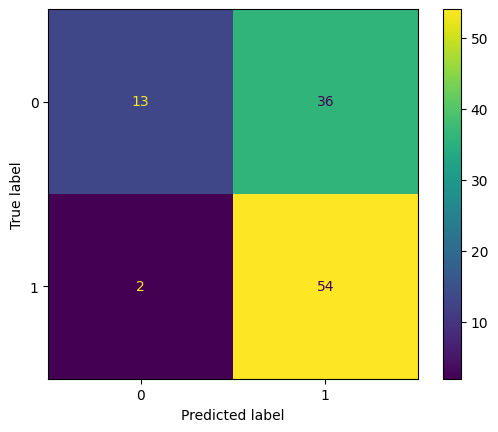

In [61]:
# Test Confusion Matrix
confusion_matrix_test = metrics.confusion_matrix(y_test, y_pred_test_class)
print(f"Die Konfusionsmatrix des Training Sample ist:")
metrics.ConfusionMatrixDisplay(confusion_matrix_test).plot()

### Accuracy-Score

In [62]:
print("Accuracy Score for the training set: {}".format(metrics.accuracy_score(y_train, y_pred_train_class)))
print("Accuracy Score for the test set: {}".format(metrics.accuracy_score(y_test, y_pred_test_class)))

Accuracy Score for the training set: 0.680327868852459
Accuracy Score for the test set: 0.638095238095238


Interpretation: Die Klassenverteilung liegt bei etwa 50/50. Wir haben also schon mal etwas gelernt mit dem Modell.

### Precision und Recall

In [63]:
# Precision
print("Precision score for the training set: {}" .format(metrics.precision_score(y_train,y_pred_train_class)))
print("Precision score for the test set: {}" .format(metrics.precision_score(y_test,y_pred_test_class)))
# Recall
print("Recall score for the training set: {}".format(metrics.recall_score(y_train,y_pred_train_class)))
print("Recall score for the test set: {}".format(metrics.recall_score(y_test,y_pred_test_class)))

Precision score for the training set: 0.6326530612244898
Precision score for the test set: 0.6
Recall score for the training set: 0.9538461538461539
Recall score for the test set: 0.9642857142857143


Interpretaton: 
Der Precision score ist nicht besonders hoch d.h. nicht besonders gut. Dies liegt daran, dass der Presicion score die Anzahl der korrekt vorhergesagten Positiven an allen vorhergesagten Positiven misst. Da wir einen tiefen Schwellenwert angenommen haben bei der Überführung der berechneten Wahrscheinlichkeiten in die Klassen gibt es auch viele Werte die als Positiv angenommen wurden, in Wirklichkeit aber Negativ sind. Dies wurde bei der Wahl des Schwellenwerts bewusst in Kauf genommen, da wir in der Medizin falsch-negativ möglichst vermeiden wollen und dann lieber mehr falsch-positive in Kauf nehmen und dort dann weitere Tests machen mit den Patienten, um eine Diagnose zu stellen.
Der Recall-Wert ist sehr hoch, d.h. gut. Dies liegt ebenfalls an dem angenommenen Schwellenwert. Dadurch haben wir fast alle tatsächlichen Positiven auch als Positive vorhergesagt.

### F1-Score

In [64]:
print("F1 score fot the training score: {}" .format(metrics.f1_score(y_train, y_pred_train_class)))
print("F1 score fot the test score: {}" .format(metrics.f1_score(y_test, y_pred_test_class)))

F1 score fot the training score: 0.7607361963190185
F1 score fot the test score: 0.7397260273972602


Der F1-Score vereint den Precision und Recall und ist dementsprechend in etwas in der Mitte der beiden Werte. Der Wert ist nicht schlecht, hat aber auch noch Optimierungspotenzial.

### Area under the Curve (AOC)

In [65]:
# AUC for train
fpr, tpr, thresholds = metrics.roc_curve(y_train, y_pred_train_class)
print("AUC score for the training set: {}".format(metrics.auc(fpr, tpr)))
# AUC for test
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_test_class)
print("AUC score for the test set: {}".format(metrics.auc(fpr, tpr)))

AUC score for the training set: 0.6611336032388665
AUC score for the test set: 0.6147959183673469


Der AUC score weist darauf hin, dass das Modell nur eine begrenzte Fahigkeit hat, korrekte Vorhersagen zu treffen. 

Zusammenfassend lässt sich sagen, dass das Modell einen Lerneffekt hat. Der Lerneffekt ist allerdings nicht sehr ausgeprägt. Zudem zeigt das Modell eine ganz leichtes Overfitting, das es im Training etwas besser vorhersagt als im Test. Das Overfitting ist jedoch nicht in einem inakzeptablen Rahmen. Es lohnt sich aber sicherlich weitere Modelle auszuprobieren, um die Vorhersagequalität zu verbessern. 
